In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
xgb_model = joblib.load('../models/xgb_creditrisk.pkl')

df_test    = pd.read_parquet('../data/test_processed.parquet')
df_lgd_raw = pd.read_parquet('../data/lgd_dataset.parquet')
lgd_table  = pd.read_csv('../data/lgd_table_grade_term.csv')

# Features para PD (39 features Semana 2)
feature_cols = [c for c in df_test.columns if c != 'default']

In [3]:
pd_scores = xgb_model.predict_proba(df_test[feature_cols])[:, 1]
print(f"PD media (test): {pd_scores.mean():.4f}")
print(f"PD mediana:      {np.median(pd_scores):.4f}")

PD media (test): 0.4660
PD mediana:      0.4785


In [4]:
df_eda = pd.read_parquet('../data/creditrisk360_eda.parquet')

# Mismo split exacto que Semana 2
df_eda_test = df_eda[df_eda['issue_year'] > 2016].reset_index(drop=True).copy()
df_eda_test['term_clean'] = df_eda_test['term'].str.strip()

assert len(df_eda_test) == len(df_test), \
    f"Shape mismatch: eda={len(df_eda_test)} vs test={len(df_test)}"

print(f"df_eda_test shape: {df_eda_test.shape}  OK")

df_eda_test shape: (97761, 42)  OK


In [5]:
DEFAULT_STATUS = [
    'Charged Off',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
]

# Para defaults reales: funded_amnt - total_rec_prncp (saldo pendiente real)
# Para performing:      funded_amnt completo (exposición actual)
mask_default = df_eda_test['loan_status'].isin(DEFAULT_STATUS)

df_eda_test['ead'] = df_eda_test['funded_amnt'].copy()
df_eda_test.loc[mask_default, 'ead'] = (
    df_eda_test.loc[mask_default, 'funded_amnt'] -
    df_eda_test.loc[mask_default, 'total_rec_prncp']
).clip(lower=0)

print(f"EAD media total:      ${df_eda_test['ead'].mean():,.2f}")
print(f"EAD media defaults:   ${df_eda_test.loc[mask_default, 'ead'].mean():,.2f}")
print(f"EAD media performing: ${df_eda_test.loc[~mask_default, 'ead'].mean():,.2f}")


EAD media total:      $13,941.91
EAD media defaults:   $13,537.45
EAD media performing: $14,083.60


In [6]:
lgd_table['term_clean'] = lgd_table['term'].str.strip()

# Crear diccionario directo evitando merge problemático
lgd_map = (lgd_table.set_index(['grade', 'term_clean'])['lgd_mean']
           .to_dict())

df_eda_test['lgd_estimated'] = (
    df_eda_test.set_index(['grade', 'term_clean'])
    .index.map(lgd_map)
)

# Fallback grade
lgd_grade_map = df_lgd_raw.groupby('grade')['lgd'].mean().to_dict()
mask_null = df_eda_test['lgd_estimated'].isna()
df_eda_test.loc[mask_null, 'lgd_estimated'] = (
    df_eda_test.loc[mask_null, 'grade'].map(lgd_grade_map)
)
df_eda_test['lgd_estimated'] = df_eda_test['lgd_estimated'].fillna(0.93)

print(f"df_eda_test shape: {df_eda_test.shape}")
print(f"EAD media:  ${df_eda_test['ead'].mean():,.2f}")
print(f"LGD media:  {df_eda_test['lgd_estimated'].mean():.4f}")
print(f"Nulos LGD:  {df_eda_test['lgd_estimated'].isna().sum()}")

df_eda_test shape: (97761, 44)
EAD media:  $13,941.91
LGD media:  0.9342
Nulos LGD:  0


In [7]:
df_eda_test['pd_score'] = pd_scores
df_eda_test['el']       = df_eda_test['pd_score'] * df_eda_test['lgd_estimated'] * df_eda_test['ead']
df_eda_test['el_rate']  = df_eda_test['pd_score'] * df_eda_test['lgd_estimated']
print(f"\n=== Expected Loss — Portfolio Test ===")
print(f"EL total:          ${df_eda_test['el'].sum():>15,.0f}")
print(f"EAD total:         ${df_eda_test['ead'].sum():>15,.0f}")
print(f"EL / EAD (ratio):  {df_eda_test['el'].sum() / df_eda_test['ead'].sum():.4f}")
print(f"EL media por loan: ${df_eda_test['el'].mean():>15,.2f}")
print(f"PD media:          {df_eda_test['pd_score'].mean():.4f}")
print(f"LGD media:         {df_eda_test['lgd_estimated'].mean():.4f}")
print(f"EAD media:         ${df_eda_test['ead'].mean():>15,.2f}")


=== Expected Loss — Portfolio Test ===
EL total:          $    609,434,943
EAD total:         $  1,362,975,070
EL / EAD (ratio):  0.4471
EL media por loan: $       6,233.93
PD media:          0.4660
LGD media:         0.9342
EAD media:         $      13,941.91


In [8]:
print(f"Default rate real test: {df_test['default'].mean():.4f}")
print(f"PD media modelo:        {pd_scores.mean():.4f}")
print(f"PD < 0.5: {(pd_scores < 0.5).mean()*100:.1f}%")
print(f"PD > 0.5: {(pd_scores > 0.5).mean()*100:.1f}%")

# ¿Cómo se llamaba el modelo guardado?
import os
modelos = [f for f in os.listdir('../models')]
print(sorted(modelos))

Default rate real test: 0.2723
PD media modelo:        0.4660
PD < 0.5: 54.2%
PD > 0.5: 45.8%
['lgd_stage1_classifier.pkl', 'lgd_stage2_regressor.pkl', 'lr_baseline.pkl', 'xgb_creditrisk.pkl', 'xgb_creditrisk_calibrated.pkl']


In [9]:
from sklearn.calibration import CalibratedClassifierCV
import joblib

# Cargar modelo correcto
xgb_model = joblib.load('../models/xgb_creditrisk.pkl')

# Verificar PD sin calibrar
pd_raw = xgb_model.predict_proba(df_test[feature_cols])[:, 1]
print(f"PD media sin calibrar: {pd_raw.mean():.4f}")
print(f"Default rate real:     {df_test['default'].mean():.4f}")

# Calibración isotónica sobre train
df_train = pd.read_parquet('../data/train_processed.parquet')
feature_cols = [c for c in df_train.columns if c != 'default']

X_train = df_train[feature_cols]
y_train = df_train['default']
X_test  = df_test[feature_cols]

calibrated = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')
calibrated.fit(X_train, y_train)

pd_scores = calibrated.predict_proba(X_test)[:, 1]
print(f"PD media calibrada:    {pd_scores.mean():.4f}")
print(f"PD < 0.5: {(pd_scores < 0.5).mean()*100:.1f}%")
print(f"PD > 0.5: {(pd_scores > 0.5).mean()*100:.1f}%")

# Guardar modelo calibrado
joblib.dump(calibrated, '../models/xgb_creditrisk_calibrated.pkl')

PD media sin calibrar: 0.4660
Default rate real:     0.2723
PD media calibrada:    0.2122
PD < 0.5: 94.8%
PD > 0.5: 4.6%


['../models/xgb_creditrisk_calibrated.pkl']

In [10]:
calibrated_platt = CalibratedClassifierCV(xgb_model, method='sigmoid', cv='prefit')
calibrated_platt.fit(X_train, y_train)

pd_platt = calibrated_platt.predict_proba(X_test)[:, 1]
print(f"PD media Platt:     {pd_platt.mean():.4f}")
print(f"PD media isotónica: {pd_scores.mean():.4f}")
print(f"Default rate real:  {df_test['default'].mean():.4f}")

# Elegir el más cercano al default rate real
diff_isotonic = abs(pd_scores.mean() - df_test['default'].mean())
diff_platt    = abs(pd_platt.mean()  - df_test['default'].mean())
print(f"\nDiff isotónica: {diff_isotonic:.4f}")
print(f"Diff Platt:     {diff_platt:.4f}")

PD media Platt:     0.2119
PD media isotónica: 0.2122
Default rate real:  0.2723

Diff isotónica: 0.0601
Diff Platt:     0.0603


In [11]:
# Usar PD calibrada isotónica
pd_scores = calibrated.predict_proba(X_test)[:, 1]

df_eda_test['pd_score'] = pd_scores
df_eda_test['el']       = df_eda_test['pd_score'] * df_eda_test['lgd_estimated'] * df_eda_test['ead']
df_eda_test['el_rate']  = df_eda_test['pd_score'] * df_eda_test['lgd_estimated']

print(f"\n=== Expected Loss — Portfolio Test (PD calibrada) ===")
print(f"EL total:          ${df_eda_test['el'].sum():>15,.0f}")
print(f"EAD total:         ${df_eda_test['ead'].sum():>15,.0f}")
print(f"EL / EAD (ratio):  {df_eda_test['el'].sum() / df_eda_test['ead'].sum():.4f}")
print(f"EL media por loan: ${df_eda_test['el'].mean():>15,.2f}")
print(f"PD media:          {df_eda_test['pd_score'].mean():.4f}")
print(f"LGD media:         {df_eda_test['lgd_estimated'].mean():.4f}")
print(f"EAD media:         ${df_eda_test['ead'].mean():>15,.2f}")


=== Expected Loss — Portfolio Test (PD calibrada) ===
EL total:          $    285,080,192
EAD total:         $  1,362,975,070
EL / EAD (ratio):  0.2092
EL media por loan: $       2,916.09
PD media:          0.2122
LGD media:         0.9342
EAD media:         $      13,941.91


In [12]:
# Por grade
el_grade = (df_eda_test.groupby('grade')
            .agg(
                pd_media=('pd_score', 'mean'),
                lgd_media=('lgd_estimated', 'mean'),
                ead_media=('ead', 'mean'),
                el_media=('el', 'mean'),
                el_total=('el', 'sum'),
                n=('el', 'count')
            ).round(4).reset_index())
el_grade['el_rate'] = (el_grade['pd_media'] * el_grade['lgd_media']).round(4)

print("\n=== EL por Grade ===")
print(el_grade.to_string(index=False))

# Por term
el_term = (df_eda_test.groupby('term_clean')
           .agg(
               pd_media=('pd_score', 'mean'),
               lgd_media=('lgd_estimated', 'mean'),
               ead_media=('ead', 'mean'),
               el_media=('el', 'mean'),
               el_total=('el', 'sum'),
               n=('el', 'count')
           ).round(4).reset_index())

print("\n=== EL por Term ===")
print(el_term.to_string(index=False))

# Por vintage (año de originación)
df_eda_test['issue_d_dt'] = pd.to_datetime(df_eda_test['issue_d'], format='%b-%Y', errors='coerce')
df_eda_test['vintage'] = df_eda_test['issue_d_dt'].dt.year
el_vintage = (df_eda_test.groupby('vintage')
              .agg(
                  pd_media=('pd_score', 'mean'),
                  el_media=('el', 'mean'),
                  el_total=('el', 'sum'),
                  n=('el', 'count')
              ).round(4).reset_index())

print("\n=== EL por Vintage ===")
print(el_vintage.to_string(index=False))


=== EL por Grade ===
grade  pd_media  lgd_media  ead_media   el_media     el_total     n  el_rate
    A    0.0502     0.9432 12895.1314   574.5039 9.480463e+06 16502   0.0473
    B    0.1353     0.9398 13011.8840  1650.6020 4.407272e+07 26701   0.1272
    C    0.2313     0.9325 14039.9453  3090.0526 9.401485e+07 30425   0.2157
    D    0.3274     0.9280 14839.6704  4611.8491 7.080572e+07 15353   0.3038
    E    0.4363     0.9201 15890.6599  6498.6725 3.822519e+07  5882   0.4014
    F    0.5771     0.9110 18271.6096  9618.0227 1.863973e+07  1938   0.5257
    G    0.5772     0.9086 19657.5647 10251.5799 9.841517e+06   960   0.5244

=== EL por Term ===
term_clean  pd_media  lgd_media  ead_media  el_media     el_total     n
 36 months    0.1678     0.9364 11693.5897 1772.5953 1.287507e+08 72634
 60 months    0.3406     0.9278 20441.0743 6221.5745 1.563295e+08 25127

=== EL por Vintage ===
 vintage  pd_media  el_media     el_total     n
    2017    0.2167 2911.4899 2.086723e+08 71672
    2

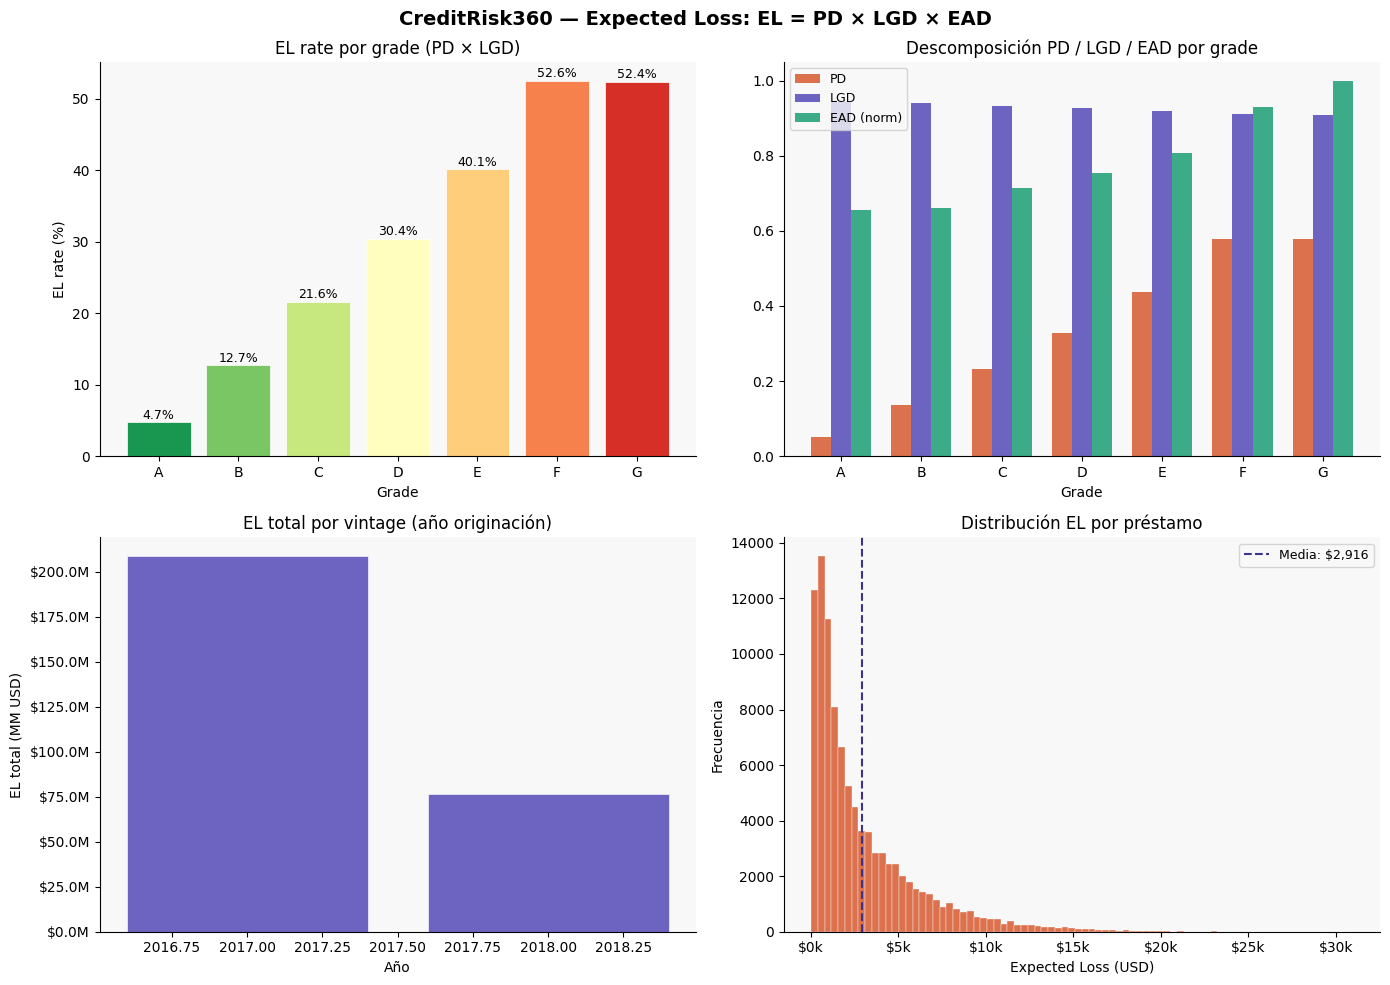

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CreditRisk360 — Expected Loss: EL = PD × LGD × EAD',
             fontsize=14, fontweight='bold')

# 8.1 EL rate por grade
ax = axes[0, 0]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(el_grade)))
bars = ax.bar(el_grade['grade'], el_grade['el_rate'] * 100,
              color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, el_grade['el_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('EL rate por grade (PD × LGD)')
ax.set_xlabel('Grade')
ax.set_ylabel('EL rate (%)')

# 8.2 Descomposición EL — PD, LGD, EAD por grade
ax = axes[0, 1]
x = np.arange(len(el_grade))
w = 0.25
ax.bar(x - w, el_grade['pd_media'], w, label='PD', color='#D85A30', alpha=0.85)
ax.bar(x,     el_grade['lgd_media'], w, label='LGD', color='#534AB7', alpha=0.85)
ax.bar(x + w, el_grade['ead_media'] / el_grade['ead_media'].max(), w,
       label='EAD (norm)', color='#1D9E75', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(el_grade['grade'])
ax.set_title('Descomposición PD / LGD / EAD por grade')
ax.set_xlabel('Grade')
ax.legend(fontsize=9)

# 8.3 EL total por vintage
ax = axes[1, 0]
ax.bar(el_vintage['vintage'], el_vintage['el_total'] / 1e6,
       color='#534AB7', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_title('EL total por vintage (año originación)')
ax.set_xlabel('Año')
ax.set_ylabel('EL total (MM USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# 8.4 Distribución EL por préstamo
ax = axes[1, 1]
ax.hist(df_eda_test['el'], bins=80, color='#D85A30',
        edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(df_eda_test['el'].mean(), color='#3C3489', lw=1.5,
           linestyle='--', label=f"Media: ${df_eda_test['el'].mean():,.0f}")
ax.set_title('Distribución EL por préstamo')
ax.set_xlabel('Expected Loss (USD)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/08_expected_loss.png', dpi=150, bbox_inches='tight')
plt.show()

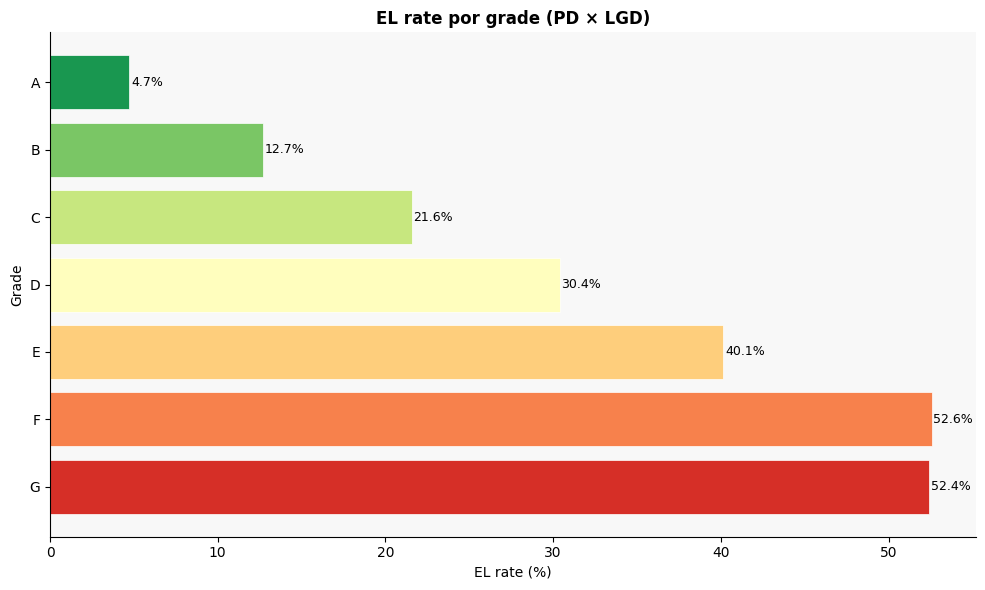

In [14]:
# 8.1 EL rate por grade (versión barras horizontales)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('EL rate por grade (PD × LGD)', fontsize=12, fontweight='bold')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(el_grade)))
bars = ax.barh(el_grade['grade'], el_grade['el_rate'] * 100,
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, el_grade['el_rate'] * 100):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=9)

ax.set_xlabel('EL rate (%)')
ax.set_ylabel('Grade')
ax.invert_yaxis()  # Opcional: para que la grade A aparezca arriba
plt.tight_layout()
plt.show()

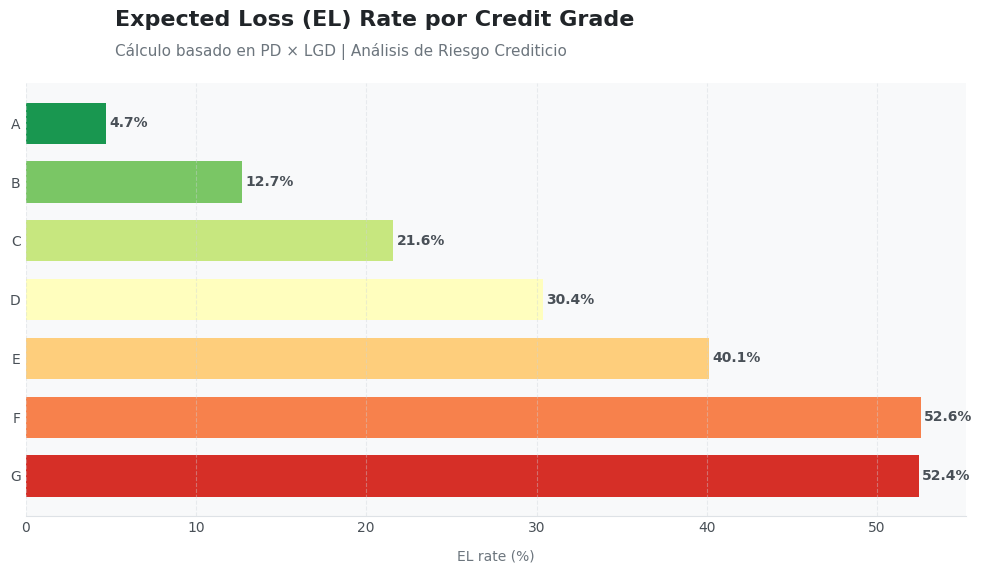

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuración estética para LinkedIn ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#F8F9FA'  # Fondo gris muy tenue

fig, ax = plt.subplots(figsize=(10, 6))

# Título con jerarquía (Título principal y subtítulo)
fig.text(0.12, 0.95, 'Expected Loss (EL) Rate por Credit Grade', 
         fontsize=16, fontweight='bold', color='#212529')
fig.text(0.12, 0.90, 'Cálculo basado en PD × LGD | Análisis de Riesgo Crediticio', 
         fontsize=11, color='#6C757D')

# Paleta de colores más suave y profesional (de Verde a Rojo)
# Invertimos para que A (menor riesgo) sea verde y G (mayor) sea rojo
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(el_grade)))

# Creación de barras con bordes redondeados (simulados con linewidth)
bars = ax.barh(el_grade['grade'], el_grade['el_rate'] * 100,
               color=colors, height=0.7, edgecolor='none')

# Etiquetas de datos personalizadas
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=10, 
            fontweight='bold', color='#495057')

# Limpieza del diseño (Despine)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#DEE2E6')
ax.spines['left'].set_visible(False)

# Ajuste de ejes
ax.set_xlabel('EL rate (%)', fontsize=10, color='#6C757D', labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=10, colors='#495057', length=0)
ax.invert_yaxis() 

# Añadir una cuadrícula sutil solo en el eje X
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#CED4DA')

plt.tight_layout(rect=[0, 0.03, 1, 0.88]) # Espacio para el título superior
plt.show()

In [15]:
df_eda_test[['pd_score', 'lgd_estimated', 'ead', 'el', 'el_rate',
             'grade', 'term_clean', 'vintage', 'funded_amnt']].to_parquet(
    '../data/expected_loss.parquet', index=False)

el_grade.to_csv('../data/el_by_grade.csv', index=False)
el_vintage.to_csv('../data/el_by_vintage.csv', index=False)

print("\nArchivos guardados:")
print("  data/expected_loss.parquet")
print("  data/el_by_grade.csv")
print("  data/el_by_vintage.csv")


Archivos guardados:
  data/expected_loss.parquet
  data/el_by_grade.csv
  data/el_by_vintage.csv
